# Student Mental Health Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (hamming_loss, f1_score,
                              classification_report)

## Load Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/alifnw/data-vault/refs/heads/main/Student%20Mental%20health.csv'

df = pd.read_csv(url)
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [ ]:
# Rename kolom biar lebih pendek
df.columns = [
    'Timestamp', 'Gender', 'Age', 'Course', 'Year',
    'CGPA', 'Marital_Status', 'Depression', 'Anxiety',
    'Panic_Attack', 'Seek_Treatment'
]

df.head()

,Timestamp,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Seek_Treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Data Cleaning

In [ ]:
df.drop(columns=["Timestamp"], inplace=True)

In [ ]:
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

In [ ]:
df["Year"] = df["Year"].str.title()

In [ ]:
course_map = {
    # KOE variants
    "koe": "KOE",
    "Koe": "KOE",

    # KIRKHS variants
    "Irkhs": "KIRKHS",
    "Kirkhs": "KIRKHS",

    # Engineering variants
    "Engine": "Engineering",
    "engin": "Engineering",
    "ENM": "Engineering",

    # Pendidikan Islam variants
    "Pendidikan islam": "Pendidikan Islam",

    # Islamic Education variants
    "Islamic education": "Islamic Education",

    # BENL variants
    "Benl": "BENL",

    # Psychology variants
    "psychology": "Psychology",

    # Usuluddin (trailing space already stripped above)
    "Usuluddin": "Usuluddin",

    # Fiqh fatwa (trailing space already stripped above)
    "Fiqh fatwa": "Fiqh Fatwa",

    "Laws":"Law"
}

df["Course"] = df["Course"].replace(course_map)

In [ ]:
for col in ["Year", "Course", "CGPA"]:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(sorted(df[col].unique()))


Year (4 unique):
['Year 1', 'Year 2', 'Year 3', 'Year 4']

Course (36 unique):
['ALA', 'Accounting', 'BCS', 'BENL', 'BIT', 'Banking Studies', 'Biomedical science', 'Biotechnology', 'Business Administration', 'CTS', 'Communication', 'DIPLOMA TESL', 'Diploma Nursing', 'Econs', 'Engineering', 'Fiqh', 'Fiqh Fatwa', 'Human Resources', 'Human Sciences', 'IT', 'Islamic Education', 'KENMS', 'KIRKHS', 'KOE', 'Kop', 'Law', 'MHSC', 'Malcom', 'Marine science', 'Mathemathics', 'Nursing', 'Pendidikan Islam', 'Psychology', 'Radiography', 'TAASL', 'Usuluddin']

CGPA (5 unique):
['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']


In [ ]:
df.head()

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Seek_Treatment
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Law,Year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,No,No,No,No,No


## Exploratory Data Analysis

### Basic Dataset Information

#### Info & Shape

In [ ]:
print('Shape:', df.shape)
df.info()

Shape: (101, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          101 non-null    object 
 1   Age             100 non-null    float64
 2   Course          101 non-null    object 
 3   Year            101 non-null    object 
 4   CGPA            101 non-null    object 
 5   Marital_Status  101 non-null    object 
 6   Depression      101 non-null    object 
 7   Anxiety         101 non-null    object 
 8   Panic_Attack    101 non-null    object 
 9   Seek_Treatment  101 non-null    object 
dtypes: float64(1), object(9)
memory usage: 8.0+ KB


#### Missing Values

In [ ]:
print('Missing values per kolom:')
print(df.isnull().sum())
print()
print('Total missing:', df.isnull().sum().sum())

Missing values per kolom:
Gender            0
Age               1
Course            0
Year              0
CGPA              0
Marital_Status    0
Depression        0
Anxiety           0
Panic_Attack      0
Seek_Treatment    0
dtype: int64

Total missing: 1


In [ ]:
# fill missing with median
df['Age'] = df['Age'].fillna(df['Age'].median())
print('Missing values per kolom:')
print(df.isnull().sum())
print()
print('Total missing:', df.isnull().sum().sum())

Missing values per kolom:
Gender            0
Age               0
Course            0
Year              0
CGPA              0
Marital_Status    0
Depression        0
Anxiety           0
Panic_Attack      0
Seek_Treatment    0
dtype: int64

Total missing: 0


In [ ]:
df.duplicated().sum()

1

In [ ]:
for col in df.columns:
    print(f"Feature: {col}")
    print(f"Unique Count: {df[col].nunique()}")
    print(f"Unique Values: {df[col].unique()}")
    print('-' * 30)

Feature: Gender
Unique Count: 2
Unique Values: ['Female' 'Male']
------------------------------
Feature: Age
Unique Count: 7
Unique Values: [18. 21. 19. 22. 23. 20. 24.]
------------------------------
Feature: Course
Unique Count: 36
Unique Values: ['Engineering' 'Islamic Education' 'BIT' 'Law' 'Mathemathics'
 'Pendidikan Islam' 'BCS' 'Human Resources' 'KIRKHS' 'Psychology' 'KENMS'
 'Accounting' 'Marine science' 'KOE' 'Banking Studies'
 'Business Administration' 'Usuluddin' 'TAASL' 'ALA' 'Biomedical science'
 'BENL' 'IT' 'CTS' 'Econs' 'MHSC' 'Malcom' 'Kop' 'Human Sciences'
 'Biotechnology' 'Communication' 'Diploma Nursing' 'Radiography'
 'Fiqh Fatwa' 'DIPLOMA TESL' 'Fiqh' 'Nursing']
------------------------------
Feature: Year
Unique Count: 4
Unique Values: ['Year 1' 'Year 2' 'Year 3' 'Year 4']
------------------------------
Feature: CGPA
Unique Count: 5
Unique Values: ['3.00 - 3.49' '3.50 - 4.00' '2.50 - 2.99' '2.00 - 2.49' '0 - 1.99']
------------------------------
Feature: Marital_S

#### Statistik Deskriptif

In [ ]:
df.describe()

,Age
count,101.000000
mean,20.514851
std,2.488429
min,18.000000
25%,18.000000
50%,19.000000
75%,23.000000
max,24.000000


### Univariate Analysis

#### Distribusi Usia

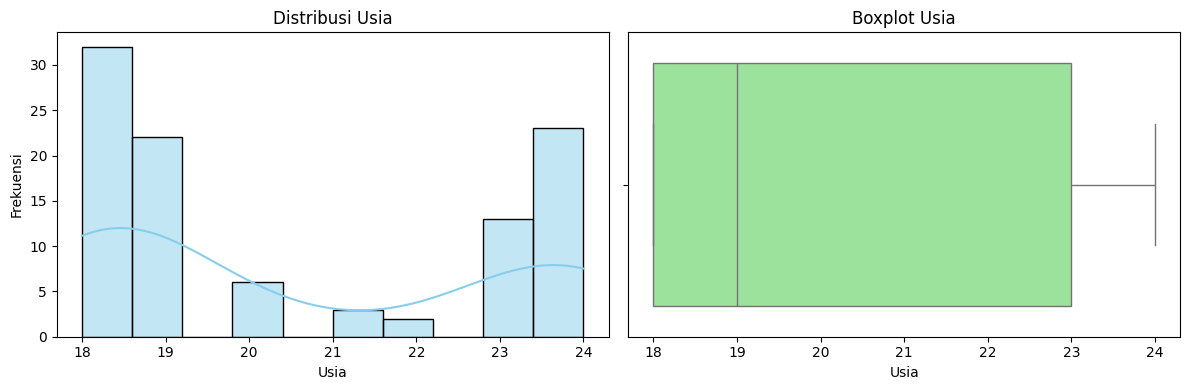

Mean Usia : 20.51
Median Usia: 19.0
Std Usia  : 2.49


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with Seaborn
sns.histplot(df['Age'], bins=10, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribusi Usia')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Frekuensi')

# Boxplot with Seaborn
sns.boxplot(x=df['Age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Usia')
axes[1].set_xlabel('Usia')

plt.tight_layout()
plt.show()

print('Mean Usia :', round(df['Age'].mean(), 2))
print('Median Usia:', df['Age'].median())
print('Std Usia  :', round(df['Age'].std(), 2))

#### Distribusi Gender

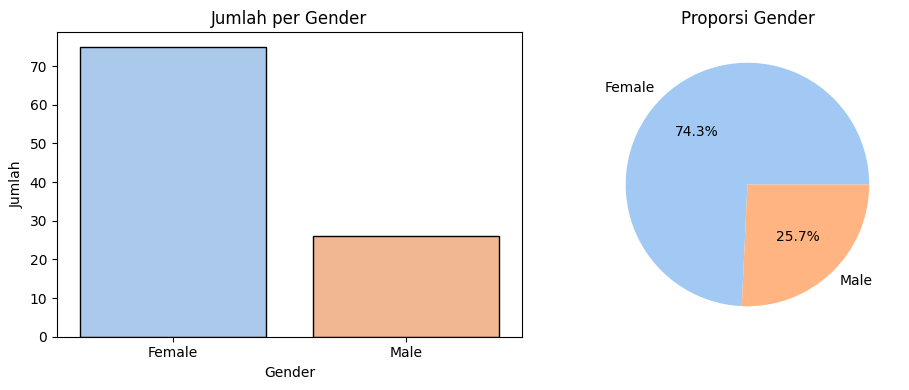

In [ ]:
gender_counts = df['Gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Countplot with Seaborn - Fixed FutureWarning
sns.countplot(data=df, x='Gender', hue='Gender', ax=axes[0], palette='pastel', edgecolor='black', legend=False)
axes[0].set_title('Jumlah per Gender')
axes[0].set_ylabel('Jumlah')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1].set_title('Proporsi Gender')

plt.tight_layout()
plt.show()

#### Distribusi Tahun Studi & CGPA

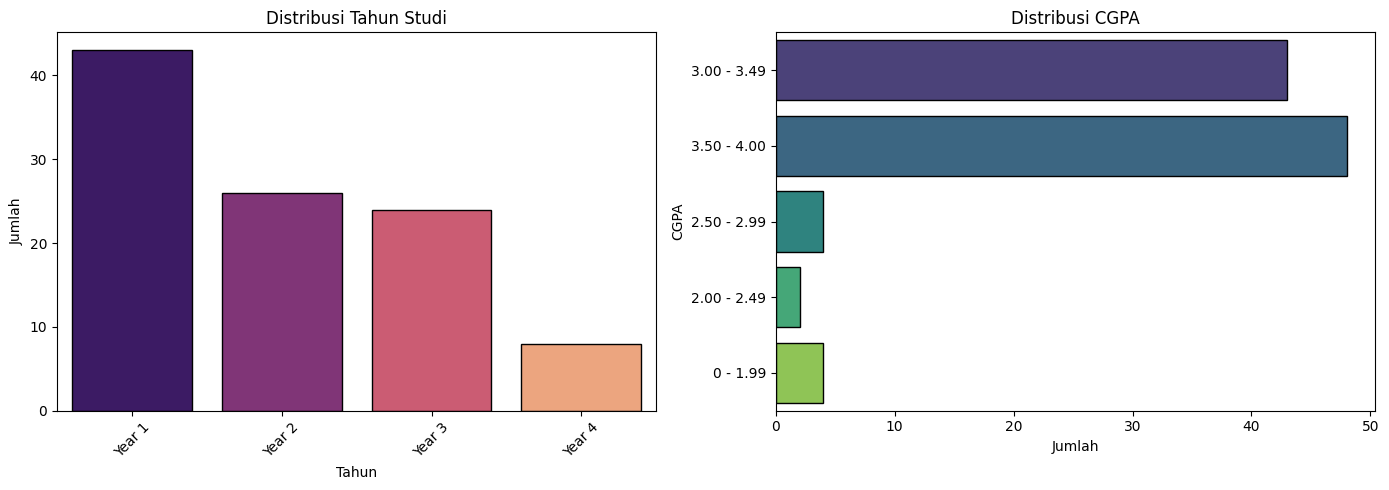

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot for Study Year - Fixed FutureWarning
sns.countplot(data=df, x='Year', hue='Year', ax=axes[0], palette='magma', edgecolor='black', order=sorted(df['Year'].unique()), legend=False)
axes[0].set_title('Distribusi Tahun Studi')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

# Countplot for CGPA - Fixed FutureWarning
sns.countplot(data=df, y='CGPA', hue='CGPA', ax=axes[1], palette='viridis', edgecolor='black', legend=False)
axes[1].set_title('Distribusi CGPA')
axes[1].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

#### Prevalensi Masalah Kesehatan Mental

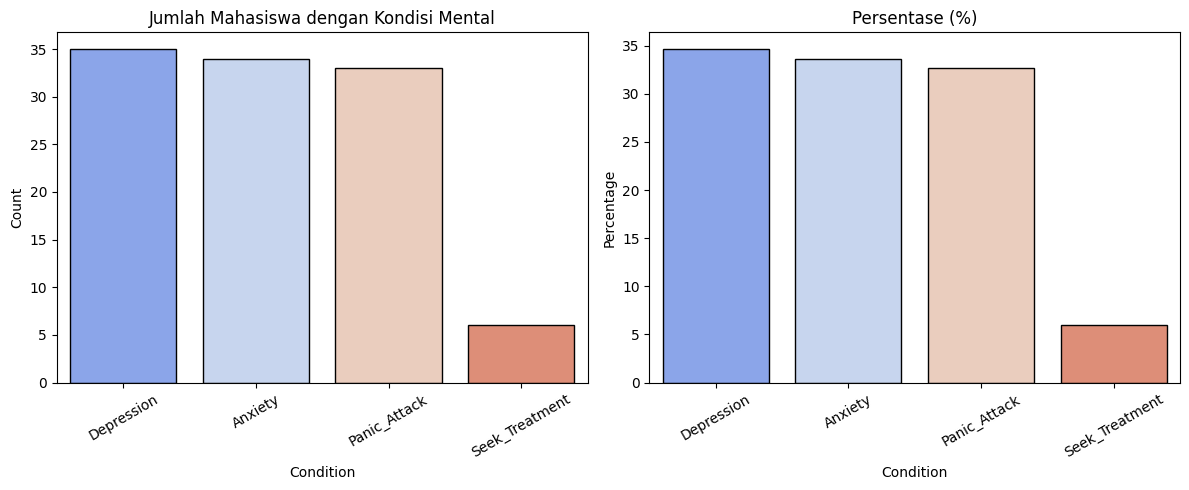

In [ ]:
mental_health_cols = ['Depression', 'Anxiety', 'Panic_Attack', 'Seek_Treatment']
prevalence_data = pd.DataFrame({
    'Condition': mental_health_cols,
    'Count': [(df[col] == 'Yes').sum() for col in mental_health_cols],
    'Percentage': [(df[col] == 'Yes').mean() * 100 for col in mental_health_cols]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=prevalence_data, x='Condition', y='Count', ax=axes[0], palette='coolwarm', edgecolor='black', hue='Condition', legend=False)
axes[0].set_title('Jumlah Mahasiswa dengan Kondisi Mental')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=prevalence_data, x='Condition', y='Percentage', ax=axes[1], palette='coolwarm', edgecolor='black', hue='Condition', legend=False)
axes[1].set_title('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### 10 Jurusan Terbanyak

Course
Engineering           21
BCS                   18
BIT                   10
KOE                    6
Biomedical science     4
Law                    3
Pendidikan Islam       3
BENL                   3
KIRKHS                 3
Psychology             3
Name: count, dtype: int64


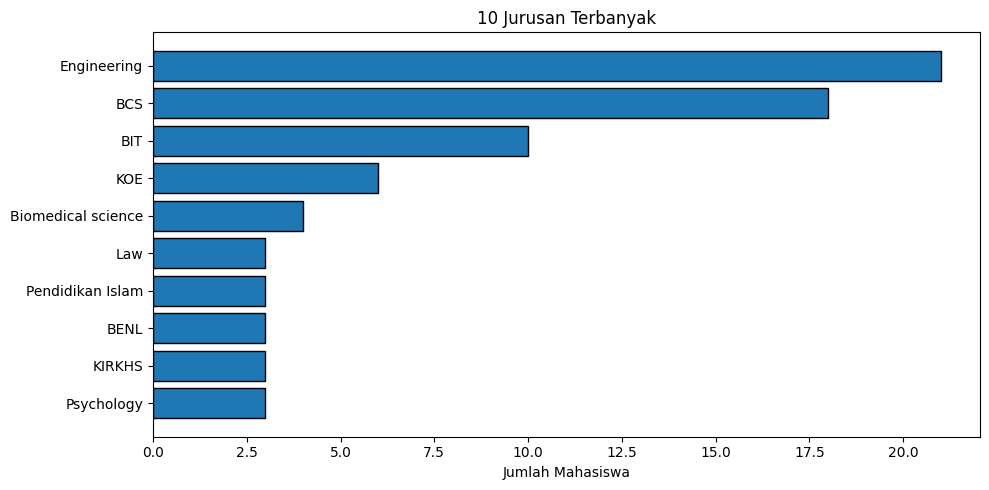

In [ ]:
top_courses = df['Course'].value_counts().head(10)
print(top_courses)

plt.figure(figsize=(10, 5))
plt.barh(top_courses.index[::-1], top_courses.values[::-1], edgecolor='black')
plt.title('10 Jurusan Terbanyak')
plt.xlabel('Jumlah Mahasiswa')
plt.tight_layout()
plt.show()

#### Target

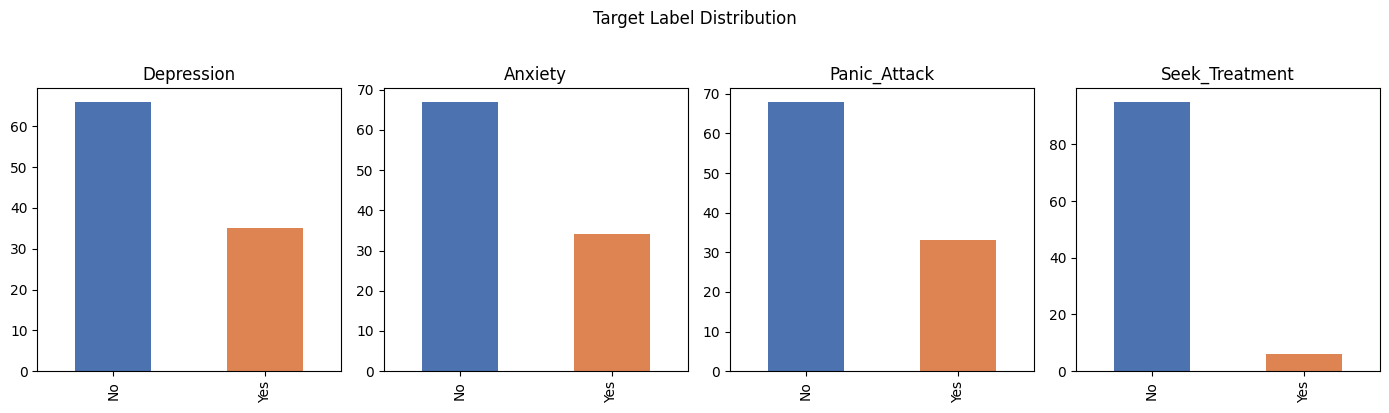


Label Co-occurrence Matrix:
                Depression  Anxiety  Panic_Attack  Seek_Treatment
Depression              35       18            17               6
Anxiety                 18       34            13               3
Panic_Attack            17       13            33               4
Seek_Treatment           6        3             4               6


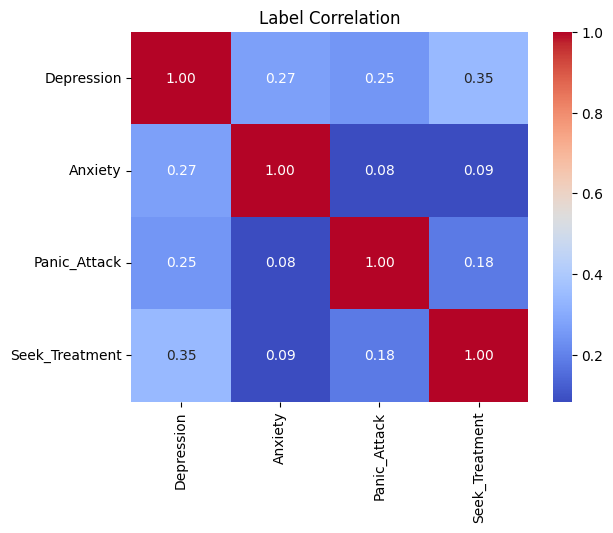

In [ ]:
targets = ["Depression", "Anxiety", "Panic_Attack", "Seek_Treatment"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, targets):
    df[col].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452"])
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Target Label Distribution", y=1.02)
plt.tight_layout()
plt.show()

# ── 2.2 Label co-occurrence (how often labels appear together) ──────
target_encoded = df[targets].apply(lambda col: col.map({"Yes": 1, "No": 0}))
print("\nLabel Co-occurrence Matrix:")
print(target_encoded.T.dot(target_encoded))

sns.heatmap(target_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Label Correlation")
plt.show()


### Bivariate Analysis

#### Kondisi Mental Berdasarkan Gender

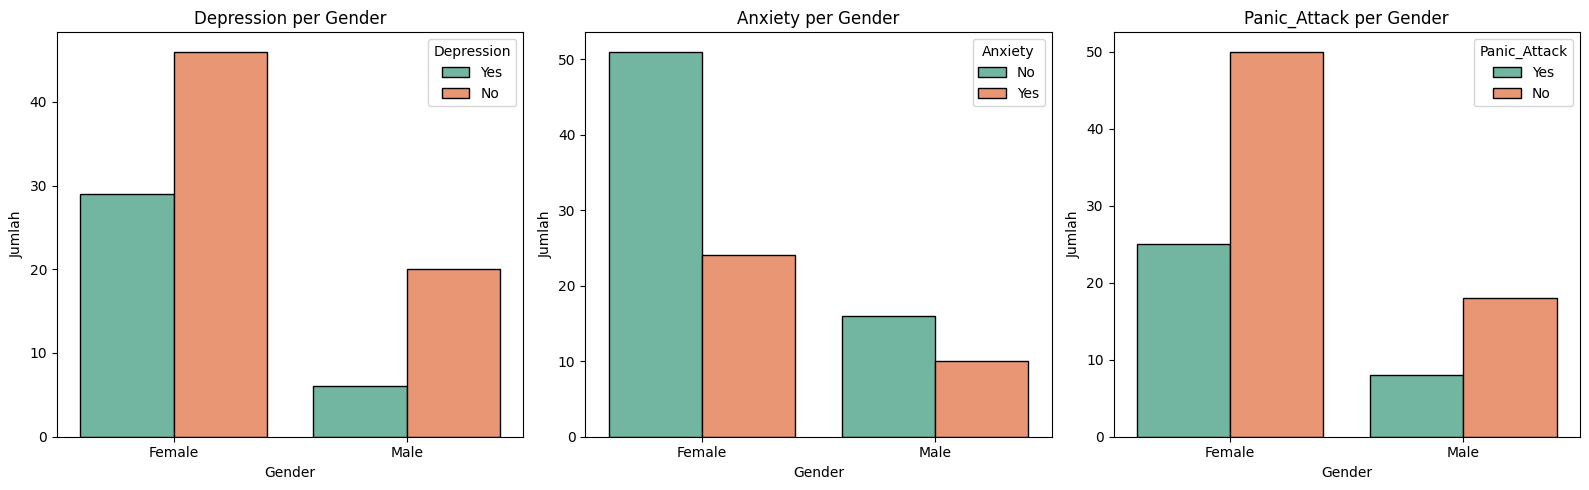

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mental_health_indicators = ['Depression', 'Anxiety', 'Panic_Attack']

for i, col in enumerate(mental_health_indicators):
    sns.countplot(data=df, x='Gender', hue=col, ax=axes[i], palette='Set2', edgecolor='black')
    axes[i].set_title(f'{col} per Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

#### Analisis Statistik: Chi-Square Test (Gender vs. Kondisi Mental)

Kita akan menggunakan Chi-square test untuk melihat apakah ada hubungan yang signifikan antara Gender dengan kondisi mental (Depression, Anxiety, Panic Attack).

In [ ]:
from scipy.stats import chi2_contingency

print('Chi-square test untuk Gender vs. Kondisi Mental:')

mental_health_cols = ['Depression', 'Anxiety', 'Panic_Attack']

for col in mental_health_cols:
    contingency_table = pd.crosstab(df['Gender'], df[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'\n--- {col} vs. Gender ---')
    print('Tabel Kontingensi:')
    print(contingency_table)
    print(f'Chi2: {chi2:.2f}')
    print(f'P-value: {p_value:.3f}')
    if p_value < 0.05:
        print('Ada hubungan yang signifikan (p < 0.05)')
    else:
        print('Tidak ada hubungan yang signifikan (p >= 0.05)')

Chi-square test untuk Gender vs. Kondisi Mental:

--- Depression vs. Gender ---
Tabel Kontingensi:
Depression  No  Yes
Gender             
Female      46   29
Male        20    6
Chi2: 1.44
P-value: 0.230
Tidak ada hubungan yang signifikan (p >= 0.05)

--- Anxiety vs. Gender ---
Tabel Kontingensi:
Anxiety  No  Yes
Gender          
Female   51   24
Male     16   10
Chi2: 0.13
P-value: 0.719
Tidak ada hubungan yang signifikan (p >= 0.05)

--- Panic_Attack vs. Gender ---
Tabel Kontingensi:
Panic_Attack  No  Yes
Gender               
Female        50   25
Male          18    8
Chi2: 0.00
P-value: 1.000
Tidak ada hubungan yang signifikan (p >= 0.05)


#### Visualisasi Mental Health Condition vs Gender


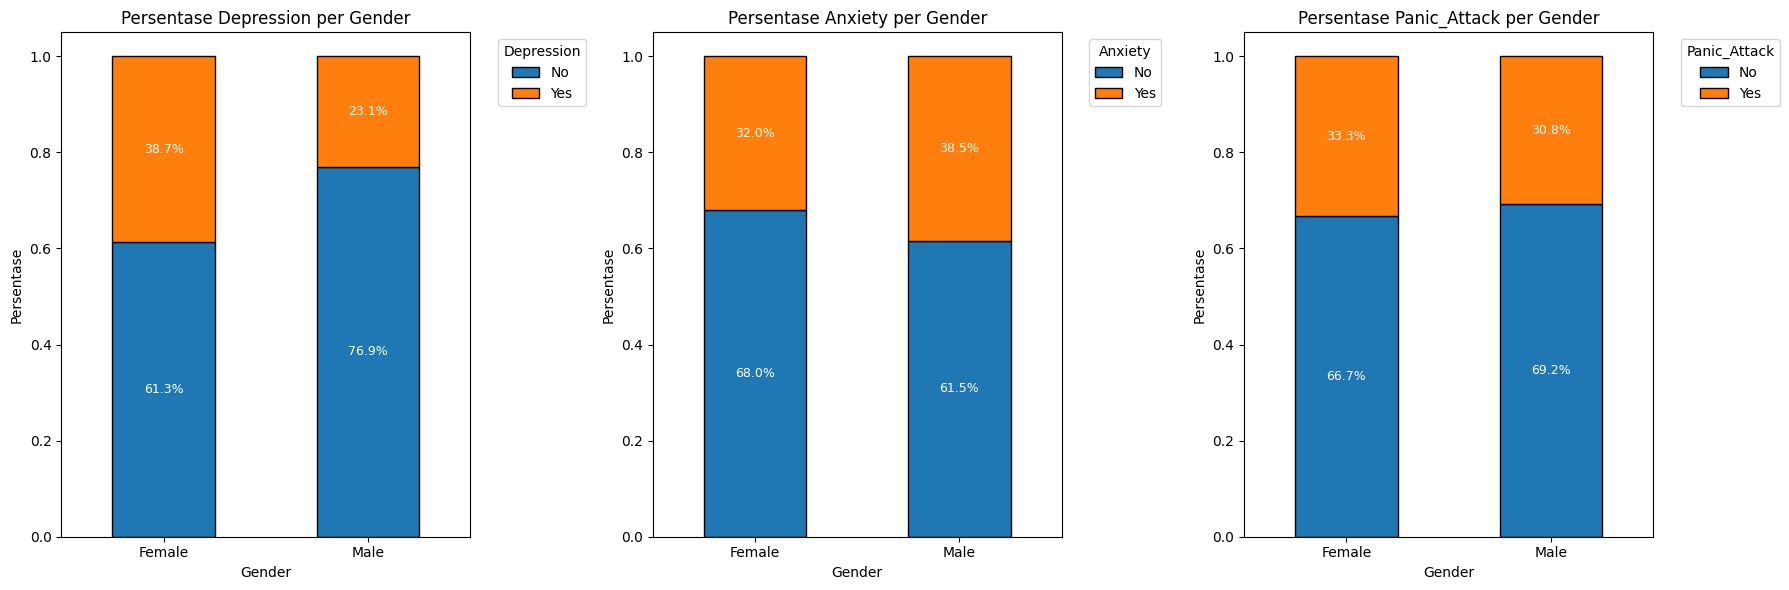

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['Gender'], df[col])
    ct_pct = ct.div(ct.sum(1).astype(float), axis=0)

    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Persentase {col} per Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('Persentase')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Annotate bars with percentages
    for container in axes[i].containers:
        for j, rect in enumerate(container):
            height = rect.get_height()
            width = rect.get_width()
            x = rect.get_x()
            y = rect.get_y()
            if height > 0.01: # Only annotate significant percentages
                axes[i].text(x + width/2, y + height/2, f'{height*100:.1f}%',
                             ha='center', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

#### Komorbiditas Kondisi Mental

Kita akan melihat berapa banyak mahasiswa yang memiliki 2 atau 3 kondisi mental (Depression, Anxiety, Panic Attack) secara bersamaan.


In [ ]:
# # Pastikan kolom mental_health_cols sudah di-encode ke 0/1
# # Kita akan menggunakan df_encoded yang sudah dibuat sebelumnya

# # Menghitung jumlah kondisi mental per mahasiswa
# df_encoded['Num_Conditions'] = df_encoded[['Depression', 'Anxiety', 'Panic_Attack']].sum(axis=1)

# comorbidity_counts = df_encoded['Num_Conditions'].value_counts().sort_index()

# print('Distribusi jumlah kondisi mental per mahasiswa:')
# print(comorbidity_counts)

# # Menghitung mahasiswa dengan 2 atau 3 kondisi
# total_students = len(df_encoded)
# students_with_2_conditions = comorbidity_counts.get(2, 0)
# students_with_3_conditions = comorbidity_counts.get(3, 0)

# print(f'\nJumlah mahasiswa dengan 2 kondisi: {students_with_2_conditions} ({students_with_2_conditions/total_students*100:.1f}%)')
# print(f'Jumlah mahasiswa dengan 3 kondisi: {students_with_3_conditions} ({students_with_3_conditions/total_students*100:.1f}%)')

# # Visualisasi komorbiditas
# plt.figure(figsize=(8, 5))
# sns.countplot(x='Num_Conditions', data=df_encoded, palette='viridis', edgecolor='black')
# plt.title('Distribusi Jumlah Kondisi Mental per Mahasiswa')
# plt.xlabel('Jumlah Kondisi Mental (Depresi, Kecemasan, Serangan Panik)')
# plt.ylabel('Jumlah Mahasiswa')
# plt.xticks(ticks=[0, 1, 2, 3], labels=['0 Kondisi', '1 Kondisi', '2 Kondisi', '3 Kondisi'])
# plt.tight_layout()
# plt.show()

#### Kondisi Mental Berdasarkan Tahun Studi

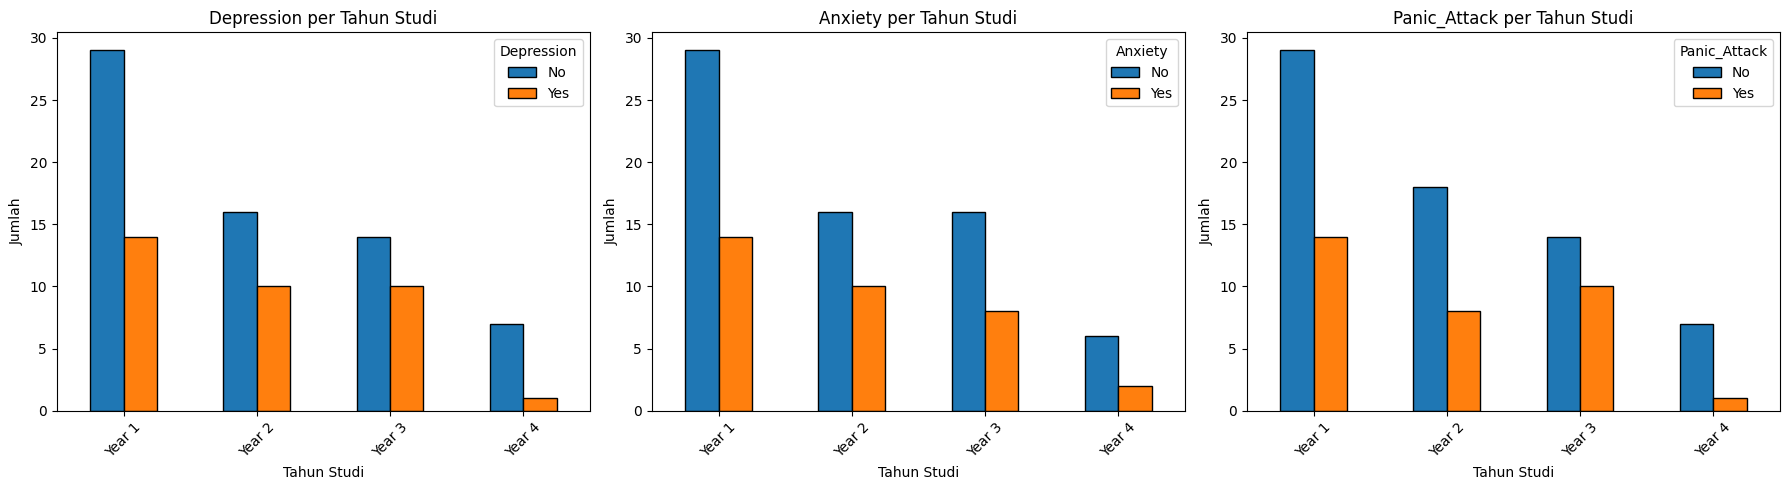

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['Year'], df[col])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} per Tahun Studi')
    axes[i].set_xlabel('Tahun Studi')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

#### Kondisi Mental Berdasarkan CGPA

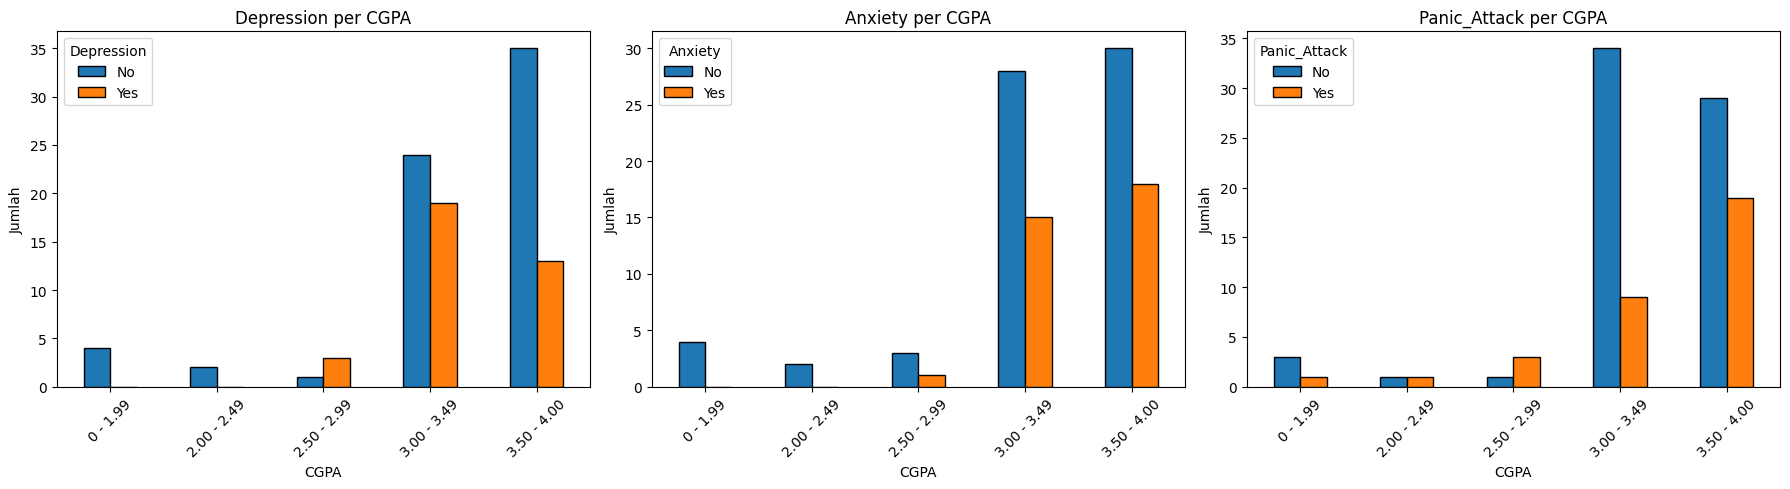

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['CGPA'], df[col])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} per CGPA')
    axes[i].set_xlabel('CGPA')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

#### Mahasiswa yang Mencari Bantuan Berdasarkan Kondisi Mental

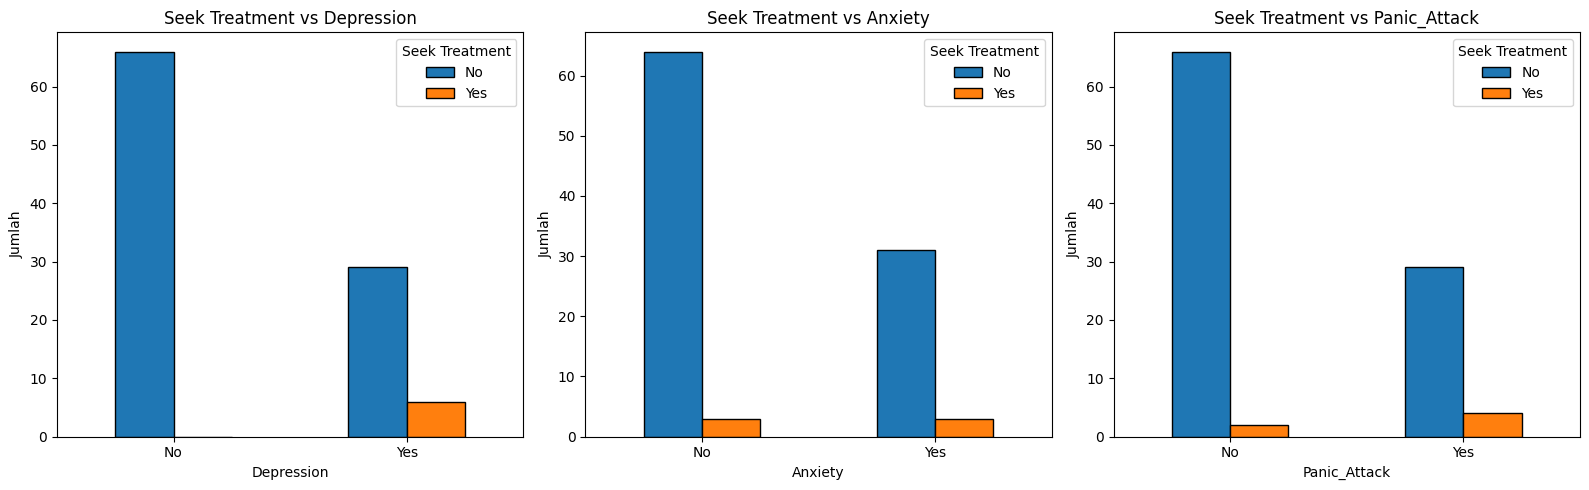

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df[col], df['Seek_Treatment'])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Seek Treatment vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Seek Treatment')

plt.tight_layout()
plt.show()

### Multivariate Analysis

#### Korelasi Antar Kondisi Mental (Heatmap)

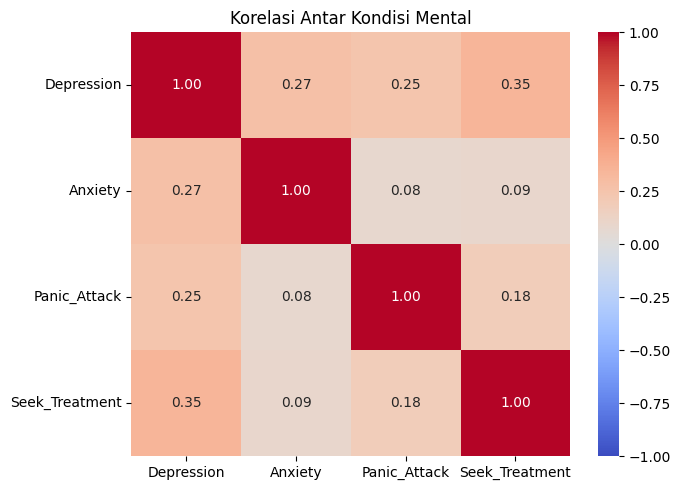

In [ ]:
# Encode Yes/No ke 1/0
binary_cols = ['Depression', 'Anxiety', 'Panic_Attack', 'Seek_Treatment']
df_encoded = df[binary_cols].copy()
for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

corr = df_encoded.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Antar Kondisi Mental')
plt.tight_layout()
plt.show()

### Ringkasan EDA

## Multiclass Output Classifier

### Train Test Split

In [ ]:

X = df.drop(columns=targets + ["Course"])
y = target_encoded

# Set random_state to 42 for consistent splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (90, 5), Test: (11, 5)


### Label Encoding

In [ ]:
# ── Binary ───────────────────────────────────────────────────────────
binary_map = {"Male": 0, "Female": 1, "No": 0, "Yes": 1}
X_train["Gender"]         = X_train["Gender"].map({"Male": 0, "Female": 1})
X_train["Marital_Status"] = X_train["Marital_Status"].map(binary_map)
X_test["Gender"]          = X_test["Gender"].map({"Male": 0, "Female": 1})
X_test["Marital_Status"]  = X_test["Marital_Status"].map(binary_map)

# ── Ordinal: Year ────────────────────────────────────────────────────
year_order = [["Year 1", "Year 2", "Year 3", "Year 4"]]
ord_enc_year = OrdinalEncoder(categories=year_order,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1)
X_train["Year"] = ord_enc_year.fit_transform(X_train[["Year"]])
X_test["Year"]  = ord_enc_year.transform(X_test[["Year"]])

# ── Ordinal: CGPA ────────────────────────────────────────────────────
cgpa_order = [["0 - 1.99", "2.00 - 2.49", "2.50 - 2.99",
                "3.00 - 3.49", "3.50 - 4.00"]]
ord_enc_cgpa = OrdinalEncoder(categories=cgpa_order,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1)
X_train["CGPA"] = ord_enc_cgpa.fit_transform(X_train[["CGPA"]])
X_test["CGPA"]  = ord_enc_cgpa.transform(X_test[["CGPA"]])

# # ── Nominal: Course (OneHot) ─────────────────────────────────────────
# ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# course_train = ohe.fit_transform(X_train[["Course"]])
# course_test  = ohe.transform(X_test[["Course"]])

# course_cols = ohe.get_feature_names_out(["Course"])
# course_train_df = pd.DataFrame(course_train, columns=course_cols,
#                                 index=X_train.index)
# course_test_df  = pd.DataFrame(course_test,  columns=course_cols,
#                                 index=X_test.index)

# X_train = X_train.drop(columns=["Course"]).join(course_train_df)
# X_test  = X_test.drop(columns=["Course"]).join(course_test_df)

### Scaling

In [ ]:
# Only Age is truly continuous here
scaler = StandardScaler()
X_train[["Age"]] = scaler.fit_transform(X_train[["Age"]])
X_test[["Age"]]  = scaler.transform(X_test[["Age"]])

### Modeling

In [ ]:
total = len(df)
print(f'Total responden     : {total}')
print(f'Rentang usia        : {int(df["Age"].min())} - {int(df["Age"].max())} tahun')
print(f'Rata-rata usia      : {round(df["Age"].mean(), 2)} tahun')
print(f'Gender dominan      : {df["Gender"].value_counts().idxmax()}')
print(f'Tahun studi terbanyak: {df["Year"].value_counts().idxmax()}')
print(f'CGPA terbanyak      : {df["CGPA"].value_counts().idxmax()}')
print()
for col in ['Depression', 'Anxiety', 'Panic_Attack', 'Seek_Treatment']:
    yes = (df[col] == 'Yes').sum()
    pct = round(yes / total * 100, 1)
    print(f'{col:30s}: {yes}/{total} ({pct}%)')

Total responden     : 101
Rentang usia        : 18 - 24 tahun
Rata-rata usia      : 20.51 tahun
Gender dominan      : Female
Tahun studi terbanyak: Year 1
CGPA terbanyak      : 3.50 - 4.00

Depression                    : 35/101 (34.7%)
Anxiety                       : 34/101 (33.7%)
Panic_Attack                  : 33/101 (32.7%)
Seek_Treatment                : 6/101 (5.9%)


### SMOTE

In [ ]:
# Using random_state=42 for SMOTE consistency
# X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
# print(f"\nSetelah SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC

nb  = MultiOutputClassifier(BernoulliNB())
nb.fit(X_train, y_train)

svm = MultiOutputClassifier(SVC(kernel="linear",
                                 class_weight="balanced",
                                 probability=True))
svm.fit(X_train, y_train)

# ── Baseline ─────────────────────────────────────────────────────────
baseline = MultiOutputClassifier(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)
baseline.fit(X_train, y_train)

# ── Random Forest ────────────────────────────────────────────────────
rf = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
)
rf.fit(X_train, y_train)

print("Models trained successfully with random_state=42")

Models trained successfully with random_state=42


### Confusion Matrix

In [ ]:
# fig, ax = plt.subplots(figsize=(6, 5))
# ConfusionMatrixDisplay.from_predictions(
#     y_test, y_pred,
#     display_labels=['Tidak Berisiko', 'Berisiko'],
#     cmap='Blues', ax=ax
# )
# ax.set_title('Confusion Matrix\n(False Negative = kasus berisiko yang terlewat)')
# plt.tight_layout()
# plt.show()

### Cross-Validation & Feature Importance

In [ ]:
def evaluate(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"Hamming Loss : {hamming_loss(y_test, y_pred):.4f}")
    print(f"F1 Macro     : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1 Weighted  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("\nPer-label report:")
    print(classification_report(y_test, y_pred,
                                 target_names=targets,
                                zero_division=0))



evaluate(baseline, X_test, y_test, "Logistic Regression (Baseline)")
evaluate(rf,       X_test, y_test, "Random Forest")
evaluate(nb,      X_test, y_test, "Naive Bayes")
evaluate(svm,     X_test, y_test, "SVM")


  Logistic Regression (Baseline)
Hamming Loss : 0.3409
F1 Macro     : 0.5413
F1 Weighted  : 0.5320

Per-label report:
                precision    recall  f1-score   support

    Depression       0.75      1.00      0.86         3
       Anxiety       0.25      0.67      0.36         3
  Panic_Attack       0.50      0.40      0.44         5
Seek_Treatment       0.33      1.00      0.50         1

     micro avg       0.42      0.67      0.52        12
     macro avg       0.46      0.77      0.54        12
  weighted avg       0.49      0.67      0.53        12
   samples avg       0.42      0.36      0.38        12


  Random Forest
Hamming Loss : 0.2045
F1 Macro     : 0.4821
F1 Weighted  : 0.5655

Per-label report:
                precision    recall  f1-score   support

    Depression       0.75      1.00      0.86         3
       Anxiety       0.50      0.67      0.57         3
  Panic_Attack       0.67      0.40      0.50         5
Seek_Treatment       0.00      0.00      0.00  

In [ ]:
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# # Cross validation recall
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# recalls = cross_val_score(rf, X, y, cv=cv, scoring='recall')

# print("=== 5-Fold Cross-Validation Recall ===")
# for i, r in enumerate(recalls, 1):
#     print(f"  Fold {i}: {r:.3f}")
# print(f"  Mean Recall : {recalls.mean():.3f}")
# print(f"  Std         : {recalls.std():.3f}")

In [ ]:
# # Feature importance
# importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

# plt.figure(figsize=(7, 4))
# importances.plot(kind='barh', edgecolor='black')
# plt.title('Feature Importance (Random Forest + SMOTE)')
# plt.xlabel('Importance Score')
# plt.tight_layout()
# plt.show()

# print("\nRanking Feature")
# for feat, imp in importances.sort_values(ascending=False).items():
#     print(f"  {feat}: {imp:.3f}")

## Clustering


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Encode a fresh copy (separate from classification pipeline) ───────
df_clust = df.copy()

# Binary encoding
df_clust["Gender"]         = df_clust["Gender"].map({"Male": 0, "Female": 1})
df_clust["Marital_Status"] = df_clust["Marital_Status"].map({"No": 0, "Yes": 1})
df_clust["Depression"]     = df_clust["Depression"].map({"No": 0, "Yes": 1})
df_clust["Anxiety"]        = df_clust["Anxiety"].map({"No": 0, "Yes": 1})
df_clust["Panic_Attack"]   = df_clust["Panic_Attack"].map({"No": 0, "Yes": 1})
df_clust["Seek_Treatment"] = df_clust["Seek_Treatment"].map({"No": 0, "Yes": 1})

# Ordinal encoding
year_order = [["Year 1", "Year 2", "Year 3", "Year 4"]]
cgpa_order = [["0 - 1.99", "2.00 - 2.49", "2.50 - 2.99", "3.00 - 3.49", "3.50 - 4.00"]]

df_clust["Year"] = OrdinalEncoder(categories=year_order).fit_transform(df_clust[["Year"]])
df_clust["CGPA"] = OrdinalEncoder(categories=cgpa_order).fit_transform(df_clust[["CGPA"]])

# ── Define feature sets ───────────────────────────────────────────────
demo_features    = ["Gender", "Age", "Year", "CGPA", "Marital_Status"]
demo_mh_features = ["Gender", "Age", "Year", "CGPA", "Marital_Status",
                     "Depression", "Anxiety", "Panic_Attack"]

X_demo    = df_clust[demo_features].copy()
X_demo_mh = df_clust[demo_mh_features].copy()

# Scale
scaler_demo    = StandardScaler()
scaler_demo_mh = StandardScaler()

X_demo_scaled    = scaler_demo.fit_transform(X_demo)
X_demo_mh_scaled = scaler_demo_mh.fit_transform(X_demo_mh)

print("Demo features shape    :", X_demo_scaled.shape)
print("Demo + MH features shape:", X_demo_mh_scaled.shape)

Demo features shape    : (101, 5)
Demo + MH features shape: (101, 8)


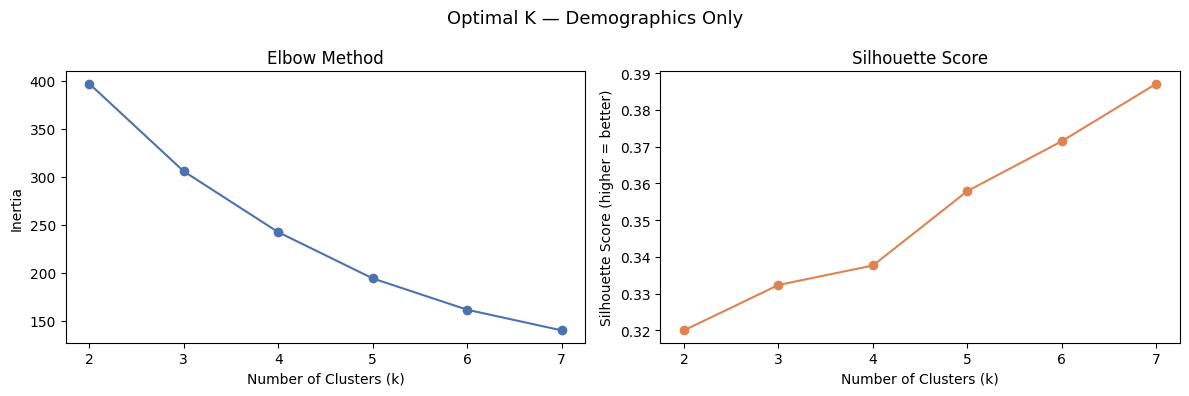

Best k by silhouette: 7 (score: 0.3871)


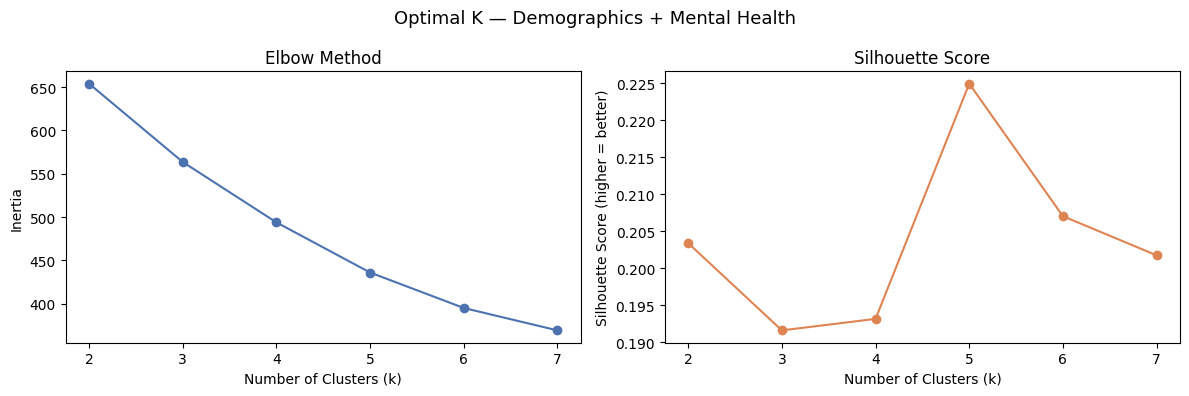

Best k by silhouette: 5 (score: 0.2249)


In [ ]:
def find_optimal_k(X_scaled, title, k_range=range(2, 8)):
    inertias, silhouettes = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Optimal K — {title}", fontsize=13)

    axes[0].plot(k_range, inertias, marker="o", color="#4C72B0")
    axes[0].set_title("Elbow Method")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia")

    axes[1].plot(k_range, silhouettes, marker="o", color="#DD8452")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score (higher = better)")

    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[silhouettes.index(max(silhouettes))]
    print(f"Best k by silhouette: {best_k} (score: {max(silhouettes):.4f})")
    return best_k

best_k_demo    = find_optimal_k(X_demo_scaled,    "Demographics Only")
best_k_demo_mh = find_optimal_k(X_demo_mh_scaled, "Demographics + Mental Health")

In [ ]:
km_demo_mh = KMeans(n_clusters=3, random_state=42, n_init=10)

df_clust["Cluster_Demo_MH"] = km_demo_mh.fit_predict(X_demo_mh_scaled)

print("\nCluster_Demo_MH distribution:")
print(df_clust["Cluster_Demo_MH"].value_counts().sort_index())


Cluster_Demo_MH distribution:
Cluster_Demo_MH
0    27
1    58
2    16
Name: count, dtype: int64


In [ ]:
def profile_clusters(df, cluster_col, features):
    print(f"\n{'='*50}")
    print(f"  Cluster Profiles — {cluster_col}")
    print(f"{'='*50}")
    profile = df.groupby(cluster_col)[features +
               ["Depression", "Anxiety", "Panic_Attack", "Seek_Treatment"]
               ].mean().round(2)
    print(profile.T)
    return profile

profile_demo_mh = profile_clusters(df_clust, "Cluster_Demo_MH", demo_mh_features)


  Cluster Profiles — Cluster_Demo_MH
Cluster_Demo_MH      0      1      2
Gender            0.70   0.74   0.81
Age              20.04  20.57  21.12
Year              0.78   0.91   1.50
CGPA              3.48   3.17   3.31
Marital_Status    0.00   0.00   1.00
Depression        0.41   0.14   1.00
Anxiety           1.00   0.00   0.44
Panic_Attack      0.30   0.26   0.62
Depression        0.41   0.14   1.00
Anxiety           1.00   0.00   0.44
Panic_Attack      0.30   0.26   0.62
Seek_Treatment    0.04   0.02   0.25


In [ ]:
from sklearn.metrics import adjusted_rand_score
from itertools import combinations
import numpy as np

labels_list = []
for seed in [0, 1, 42, 99, 123]:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_list.append(km.fit_predict(X_demo_mh_scaled))

scores = [adjusted_rand_score(a, b)
          for a, b in combinations(labels_list, 2)]
print(f"Stability ARI: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Stability ARI: 0.5004 ± 0.2588


In [ ]:
# def plot_clusters(X_scaled, labels, title):
#     pca = PCA(n_components=2, random_state=42)
#     coords = pca.fit_transform(X_scaled)
#     variance = pca.explained_variance_ratio_

#     plt.figure(figsize=(8, 5))
#     scatter = plt.scatter(coords[:, 0], coords[:, 1],
#                           c=labels, cmap="tab10", alpha=0.7, edgecolors="k", s=60)
#     plt.colorbar(scatter, label="Cluster")
#     plt.title(f"{title}\n(PCA — explains {variance.sum()*100:.1f}% variance)")
#     plt.xlabel(f"PC1 ({variance[0]*100:.1f}%)")
#     plt.ylabel(f"PC2 ({variance[1]*100:.1f}%)")
#     plt.tight_layout()
#     plt.show()

# plot_clusters(X_demo_scaled,    df_clust["Cluster_Demo"],    "Clustering — Demographics Only")
# plot_clusters(X_demo_mh_scaled, df_clust["Cluster_Demo_MH"], "Clustering — Demographics + Mental Health")

In [ ]:
import sys
# Downgrade numpy to 1.x to resolve compatibility issues with scikit-learn-extra
!{sys.executable} -m pip install "numpy<2" scikit-learn-extra

from sklearn_extra.cluster import KMedoids
from itertools import combinations
from sklearn.metrics import adjusted_rand_score
import numpy as np

# KMedoids is more robust to outliers and mixed data than KMeans
kmed = KMedoids(n_clusters=3, random_state=42, method='pam')
df_clust["Cluster_KMedoids"] = kmed.fit_predict(X_demo_mh_scaled)

# Check stability
labels_list = []
for seed in [0, 1, 42, 99, 123]:
    km = KMedoids(n_clusters=3, random_state=seed, method='pam')
    labels_list.append(km.fit_predict(X_demo_mh_scaled))

scores = [adjusted_rand_score(a, b)
          for a, b in combinations(labels_list, 2)]
print(f"KMedoids Stability ARI: {np.mean(scores):.4f} \u00b1 {np.std(scores):.4f}")

KMedoids Stability ARI: 1.0000 ± 0.0000


In [ ]:
mh_no_marital = ["Gender", "Age", "Year", "CGPA",
                  "Depression", "Anxiety", "Panic_Attack"]

X_no_marital = scaler_demo_mh.fit_transform(df_clust[mh_no_marital])

labels_list = []
for seed in [0, 1, 42, 99, 123]:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_list.append(km.fit_predict(X_no_marital))

scores = [adjusted_rand_score(a, b)
          for a, b in combinations(labels_list, 2)]
print(f"No Marital ARI: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

No Marital ARI: 0.4798 ± 0.2521


In [ ]:
labels_list = []
for seed in [0, 1, 42, 99, 123]:
    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    labels_list.append(km.fit_predict(X_demo_mh_scaled))

scores = [adjusted_rand_score(a, b)
          for a, b in combinations(labels_list, 2)]
print(f"k=2 Stability ARI: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

k=2 Stability ARI: 1.0000 ± 0.0000


In [ ]:
# Check if all runs actually produced different label assignments
for i, labels in enumerate(labels_list):
    print(f"Seed run {i}: {labels[:10]}")

Seed run 0: [1 0 1 1 0 0 1 0 0 0]
Seed run 1: [0 1 0 0 1 1 0 1 1 1]
Seed run 2: [0 1 0 0 1 1 0 1 1 1]
Seed run 3: [0 1 0 0 1 1 0 1 1 1]
Seed run 4: [1 0 1 1 0 0 1 0 0 0]


In [ ]:
# Test with genuinely different initializations
from sklearn_extra.cluster import KMedoids

labels_list = []
for init_seed in [0, 1, 42, 99, 123]:
    kmed = KMedoids(n_clusters=3,
                    random_state=init_seed,
                    method='alternate',  # ← non-deterministic, actually varies
                    init='random')       # ← forces random init per seed
    labels_list.append(kmed.fit_predict(X_demo_mh_scaled))

scores = [adjusted_rand_score(a, b)
          for a, b in combinations(labels_list, 2)]
print(f"KMedoids (alternate) ARI: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Also check labels are actually different
for i, labels in enumerate(labels_list):
    print(f"Seed {i}: {labels[:10]}")

KMedoids (alternate) ARI: 0.1940 ± 0.1027
Seed 0: [2 1 2 1 1 0 2 0 1 2]
Seed 1: [1 1 2 2 1 0 2 1 1 1]
Seed 2: [1 2 2 0 0 1 0 2 0 2]
Seed 3: [1 0 1 2 2 2 1 0 2 0]
Seed 4: [2 0 2 1 1 0 1 2 0 2]


## Risk Scoring


In [ ]:
def risk_score(row):
    conditions = (
        (row["Depression"] == "Yes") +
        (row["Anxiety"] == "Yes") +
        (row["Panic_Attack"] == "Yes")
    )
    if conditions == 0:
        return "Low"
    elif conditions == 1:
        return "Medium"
    else:
        return "High"

df["Risk_Score"] = df.apply(risk_score, axis=1)

# Also add a binary treatment gap flag — useful for Page 2
df["Treatment_Gap"] = (
    (df["Risk_Score"].isin(["Medium", "High"])) &
    (df["Seek_Treatment"] == "No")
).map({True: "Gap", False: "No Gap"})

df.to_csv("mental_health_cleaned.csv", index=False)

In [ ]:
df.head()

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Seek_Treatment,Risk_Score,Treatment_Gap
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,No,Yes,No,Yes,No,High,Gap
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,No,No,Yes,No,No,Medium,Gap
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,High,Gap
3,Female,22.0,Law,Year 3,3.00 - 3.49,Yes,Yes,No,No,No,Medium,Gap
4,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,No,No,No,No,No,Low,No Gap
